In [4]:
# Create a total points column if needed
df['Total Points'] = df['Jury Points'].fillna(0) + df['Televote Points'].fillna(0)
points_col = 'Total Points'
print("Using column:", points_col)

Using column: Total Points


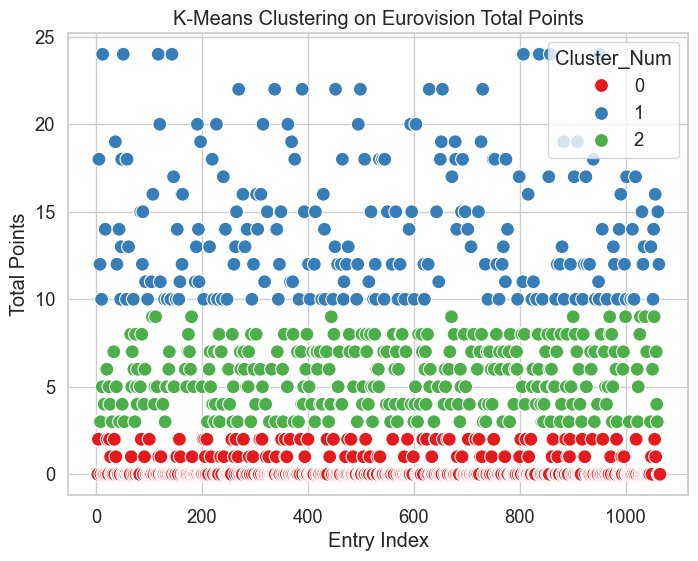

In [5]:
# Prepare numerical data
numerical_cols = [points_col]
X_num = df[numerical_cols].fillna(0)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Apply K-Means
kmeans_num = KMeans(n_clusters=3, random_state=42)
df['Cluster_Num'] = kmeans_num.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=df.index, y=df[points_col], hue=df['Cluster_Num'], palette='Set1', s=100)
plt.title('K-Means Clustering on Eurovision Total Points')
plt.xlabel('Entry Index')
plt.ylabel(points_col)
plt.show()